# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1496,71,63,"(0.1, 1.6)","(-0.082, -0.483, -0.166, -0.299)",0,1.0,"(-0.091, -0.668, -0.172, -0.225)",1.0,1.0,"(-0.105, -0.481, -0.176, -0.332)"
172,1,7,"(0.07, 1.8)","(0.013, 0.225, 0.027, -0.105)",1,1.0,"(0.018, 0.41, 0.025, -0.182)",0.0,1.0,"(0.026, 0.225, 0.021, -0.1)"
619,7,28,"(0.1, 1.0)","(0.052, 0.226, 0.013, -0.173)",0,1.0,"(0.056, 0.038, 0.009, -0.025)",0.0,1.0,"(0.057, -0.151, 0.009, 0.123)"
718,16,30,"(0.87, 1.2)","(0.004, 0.01, -0.126, -0.371)",0,1.0,"(0.005, -0.182, -0.134, -0.137)",1.0,1.0,"(0.001, 0.013, -0.136, -0.446)"
1037,27,45,"(0.95, 1.3)","(0.109, 0.183, -0.008, 0.068)",1,1.0,"(0.113, 0.378, -0.007, -0.232)",1.0,1.0,"(0.121, 0.574, -0.012, -0.532)"
...,...,...,...,...,...,...,...,...,...,...
1387,12,60,"(0.55, 1.3)","(0.047, 0.715, -0.109, -0.724)",1,1.0,"(0.062, 0.905, -0.124, -0.909)",1.0,1.0,"(0.08, 1.095, -0.142, -1.096)"
216,2,9,"(0.36, 0.2)","(0.041, -0.022, -0.006, 0.048)",1,1.0,"(0.04, 0.201, -0.005, -0.862)",0.0,1.0,"(0.044, -0.022, -0.023, 0.037)"
327,10,15,"(0.15, 1.2)","(-0.061, -1.094, 0.032, 0.709)",1,1.0,"(-0.083, -0.906, 0.046, 0.587)",1.0,1.0,"(-0.101, -0.719, 0.058, 0.467)"
1479,54,63,"(0.1, 1.6)","(0.2, -0.31, -0.17, -0.104)",1,1.0,"(0.194, -0.123, -0.172, -0.211)",0.0,1.0,"(0.191, -0.308, -0.177, -0.138)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.19514046609401703, 1.2961182594299316]","[0.20082427561283112, 1.3008476495742798]","[0.15537646412849426, 0.43978869915008545, 0.0...",1.873765,1.549301,2.229861
1,1,"[0.19560261070728302, 1.3006433248519897]","[0.20132000744342804, 1.305048942565918]","[0.15315453708171844, 0.4356555640697479, 0.02...",1.873520,1.535218,2.222818
2,2,"[0.19606001675128937, 1.3051620721817017]","[0.20180848240852356, 1.309238076210022]","[0.15097996592521667, 0.43154197931289673, 0.0...",1.873292,1.521270,2.215863
3,3,"[0.1965191513299942, 1.3096696138381958]","[0.20229999721050262, 1.3134171962738037]","[0.14885351061820984, 0.4274460971355438, 0.02...",1.873079,1.507458,2.208999
4,4,"[0.19697989523410797, 1.3141677379608154]","[0.20279306173324585, 1.3175854682922363]","[0.1467754989862442, 0.42336729168891907, 0.02...",1.872883,1.493782,2.202232


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
1496,71,63,"(0.1, 1.6)","(-0.082, -0.483, -0.166, -0.299)",0,1.0,"(-0.091, -0.668, -0.172, -0.225)",1.0,1.0,"(-0.105, -0.481, -0.176, -0.332)"
172,1,7,"(0.07, 1.8)","(0.013, 0.225, 0.027, -0.105)",1,1.0,"(0.018, 0.41, 0.025, -0.182)",0.0,1.0,"(0.026, 0.225, 0.021, -0.1)"
619,7,28,"(0.1, 1.0)","(0.052, 0.226, 0.013, -0.173)",0,1.0,"(0.056, 0.038, 0.009, -0.025)",0.0,1.0,"(0.057, -0.151, 0.009, 0.123)"
718,16,30,"(0.87, 1.2)","(0.004, 0.01, -0.126, -0.371)",0,1.0,"(0.005, -0.182, -0.134, -0.137)",1.0,1.0,"(0.001, 0.013, -0.136, -0.446)"
1037,27,45,"(0.95, 1.3)","(0.109, 0.183, -0.008, 0.068)",1,1.0,"(0.113, 0.378, -0.007, -0.232)",1.0,1.0,"(0.121, 0.574, -0.012, -0.532)"


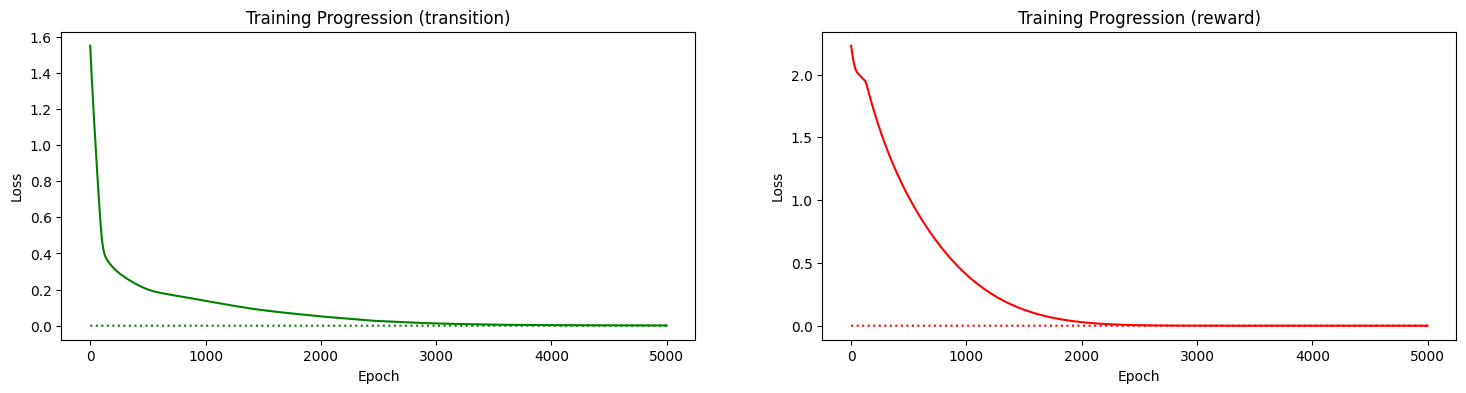

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

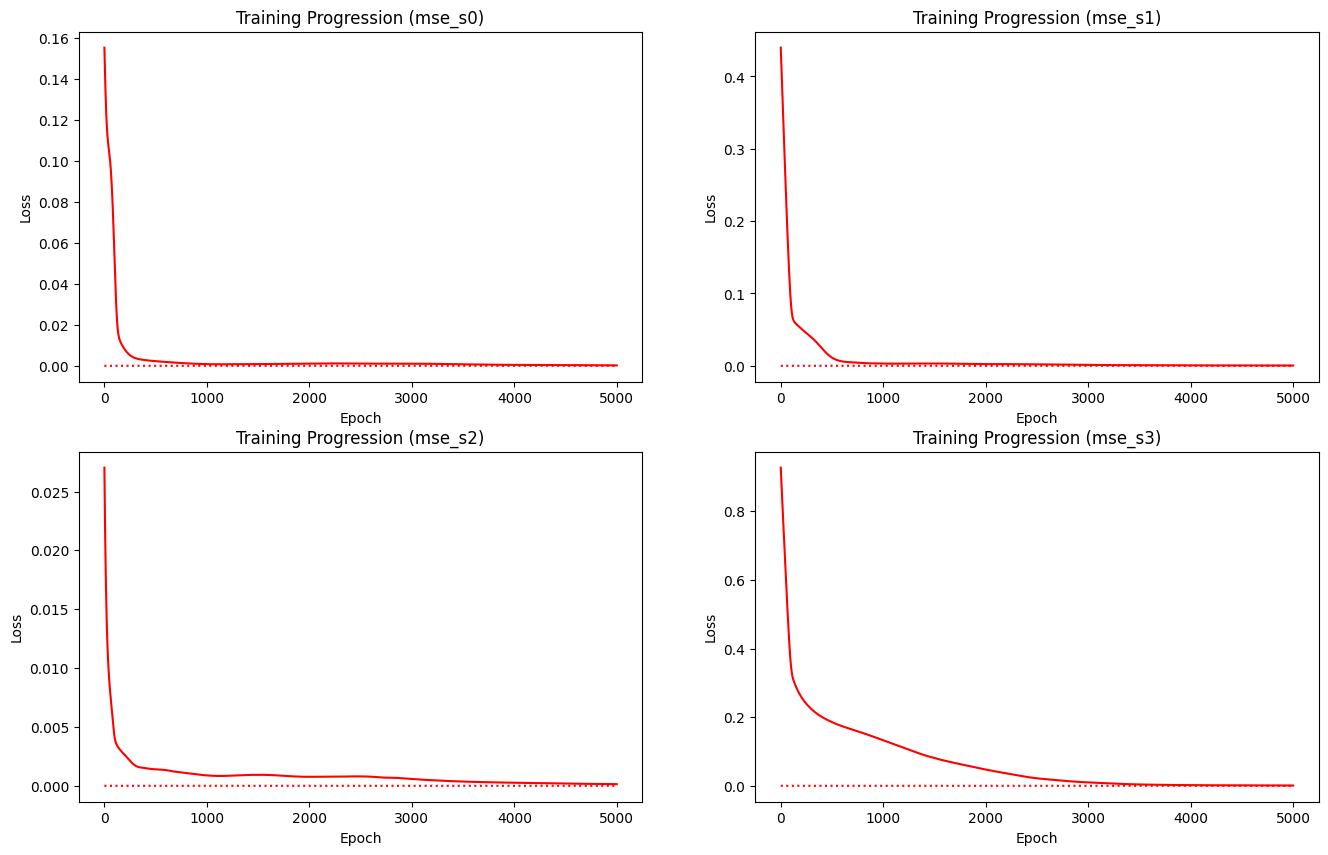

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

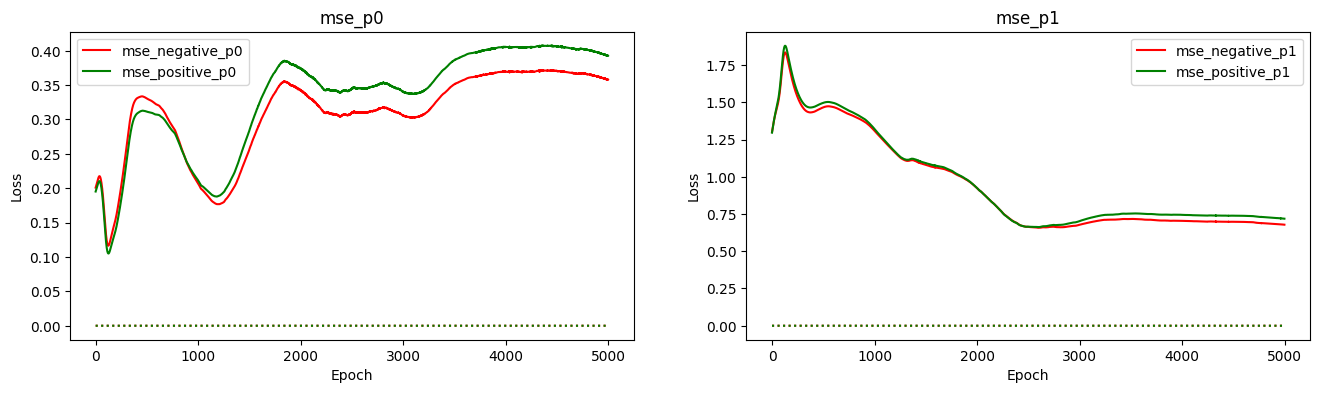

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [16]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_2849/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.10,1.6,0.10,1.4,0.518067,0.310951,0.0
1,499,0.07,1.8,0.22,0.1,0.413956,-0.068168,1.0
2,499,0.10,1.0,0.95,1.3,0.320323,0.105559,2.0
3,499,0.87,1.2,0.58,1.0,0.485509,0.171921,3.0
4,499,0.95,1.3,0.58,1.0,0.413654,-0.046864,4.0


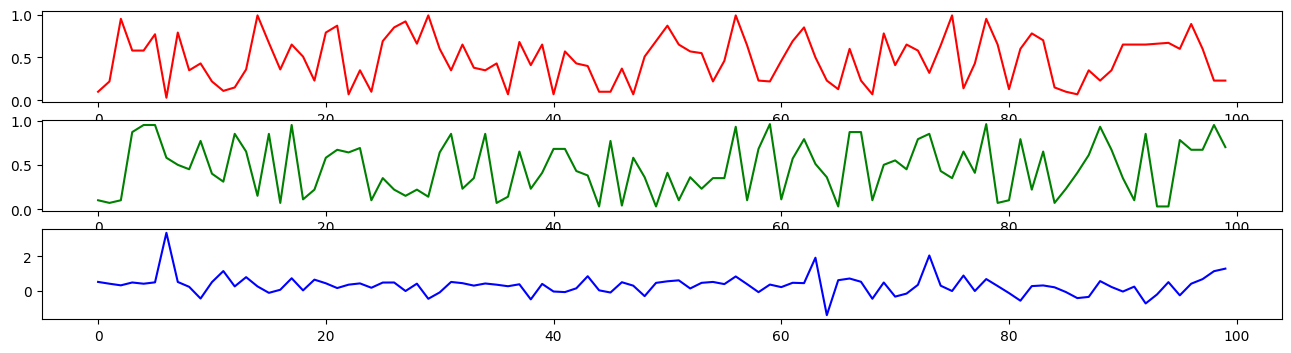

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

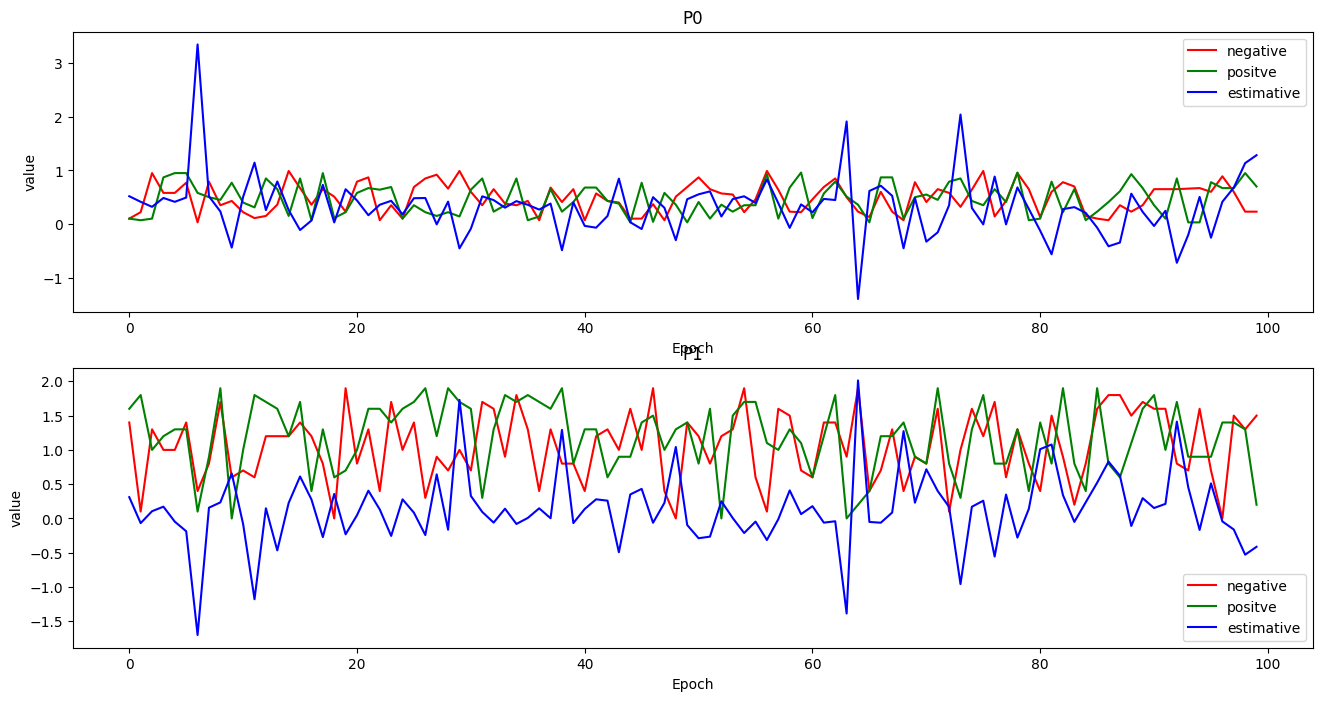

In [18]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [27]:
data.evaluate_model(model, path='training_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.58, 1.0)","(0.02, -0.037, -0.022, 0.009)",0,1.0,"(0.019, -0.229, -0.022, 0.229)",0.0,1.0,"(0.015, -0.421, -0.017, 0.449)",...,0.435,0.58,1.0,0.954,0.506,0.002,0.001,0.001,0.014,0.0
1,1,0,"(0.58, 1.0)","(0.019, -0.229, -0.022, 0.229)",0,1.0,"(0.015, -0.421, -0.017, 0.449)",0.0,1.0,"(0.006, -0.612, -0.008, 0.671)",...,0.654,0.58,1.0,0.955,0.516,0.000,0.006,0.004,0.017,0.0
2,2,0,"(0.58, 1.0)","(0.015, -0.421, -0.017, 0.449)",0,1.0,"(0.006, -0.612, -0.008, 0.671)",0.0,1.0,"(-0.006, -0.804, 0.005, 0.894)",...,0.885,0.58,1.0,0.968,0.540,0.006,0.007,0.009,0.009,0.0
3,3,0,"(0.58, 1.0)","(0.006, -0.612, -0.008, 0.671)",0,1.0,"(-0.006, -0.804, 0.005, 0.894)",1.0,1.0,"(-0.022, -0.612, 0.023, 0.67)",...,0.699,0.58,1.0,0.984,0.567,0.011,0.019,0.006,0.029,0.0
4,4,0,"(0.58, 1.0)","(-0.006, -0.804, 0.005, 0.894)",1,1.0,"(-0.022, -0.612, 0.023, 0.67)",1.0,1.0,"(-0.034, -0.421, 0.036, 0.45)",...,0.449,0.58,1.0,0.976,0.553,0.009,0.011,0.001,0.001,0.0


In [28]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([83, 71, 62]) worst_episodes=array([ 1, 22, 75])


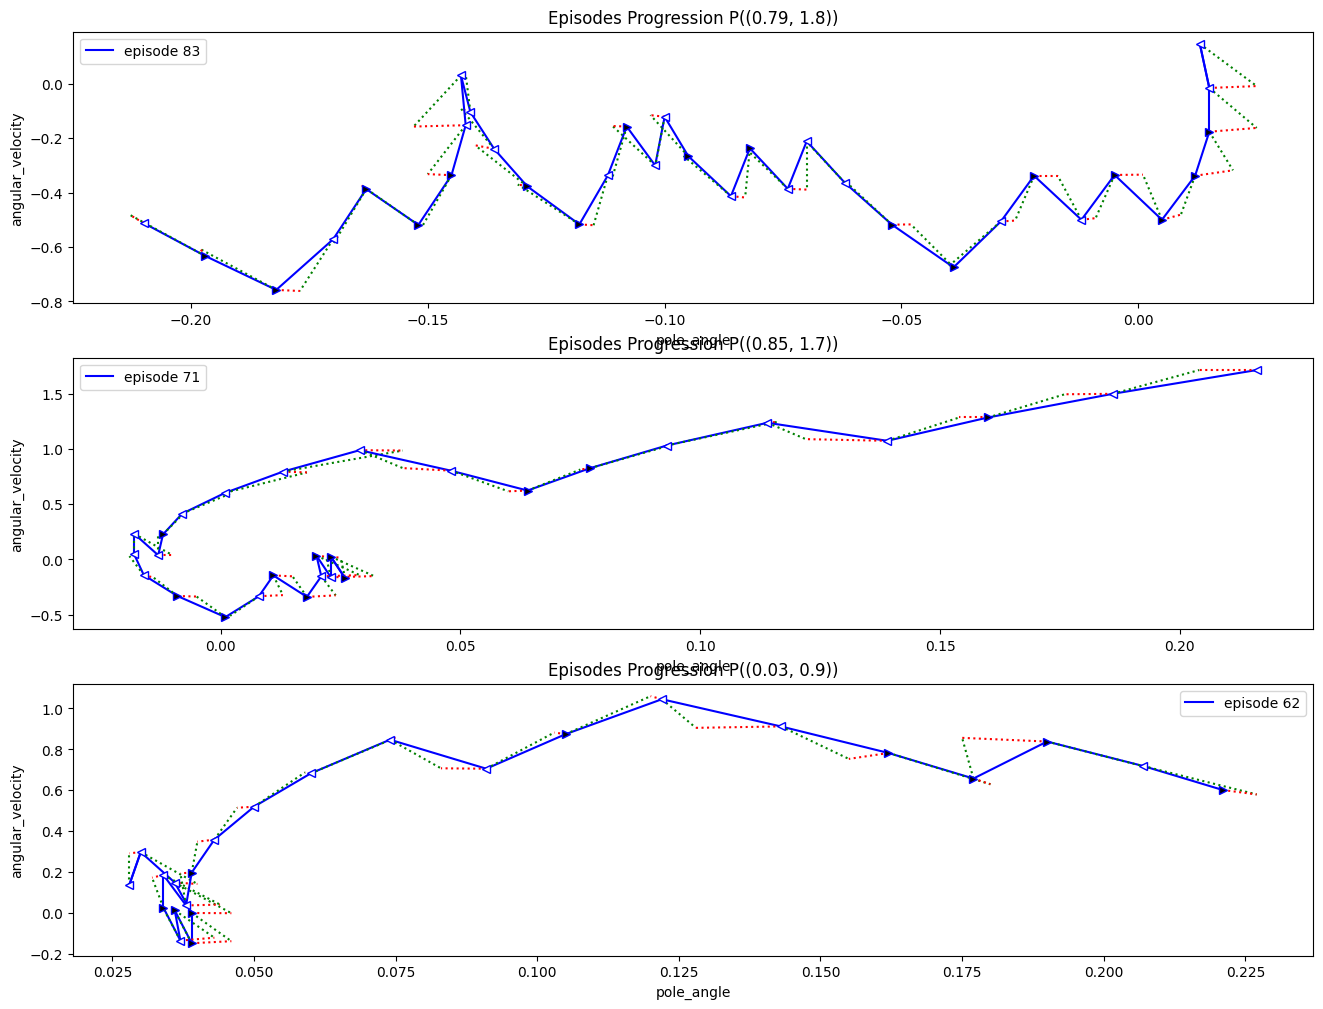

In [29]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

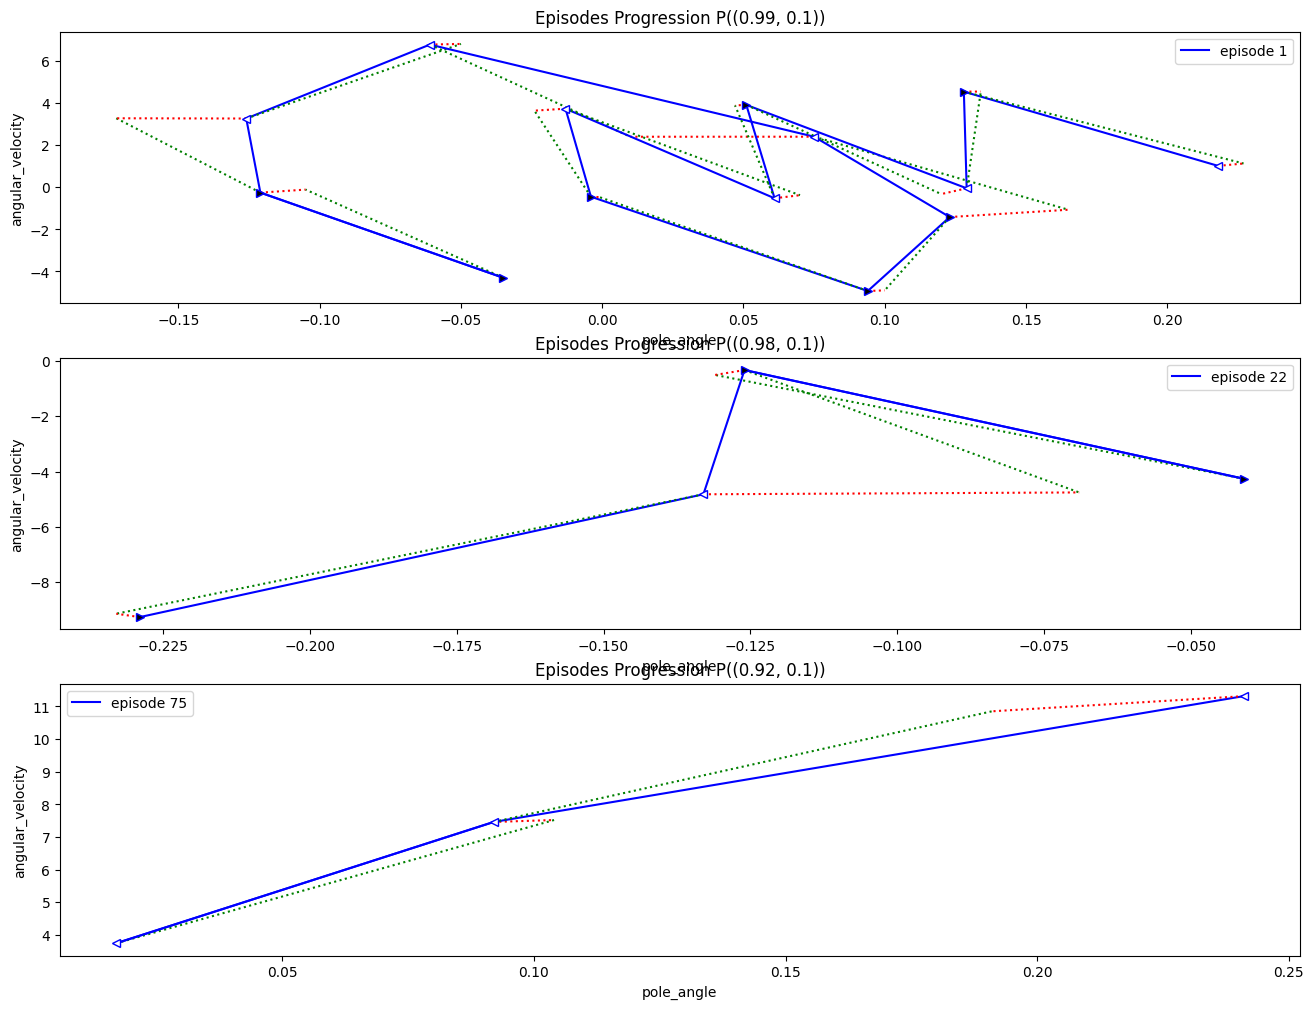

In [30]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

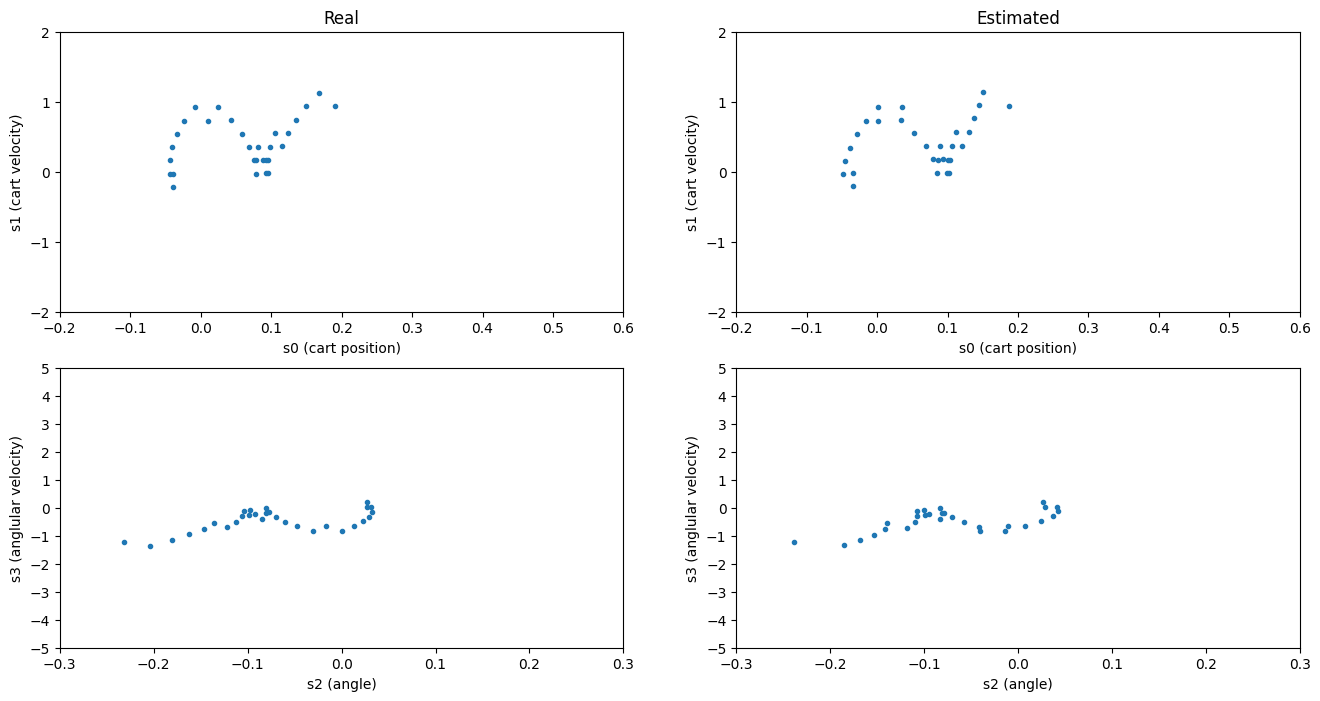

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

df = results.loc[results.episode == 3]

axs[0][0].scatter(x=df['s0'], y=df['s1'], marker='.')
axs[1][0].scatter(x=df['s2'], y=df['s3'], marker='.')

axs[0][1].scatter(x=df['estimated_s0'], y=df['estimated_s1'], marker='.')
axs[1][1].scatter(x=df['estimated_s2'], y=df['estimated_s3'], marker='.')

axs[0][0].set_title('Real')
axs[0][1].set_title('Estimated')

for i, _ in enumerate(axs[0]):
    axs[0][i].set_ylabel('s1 (cart velocity)')
    axs[0][i].set_xlabel('s0 (cart position)')
    axs[0][i].set_yticks(range(-2,3))
    axs[0][i].set_xticks([i/10 for i in range(-2,7)])

for i, _ in enumerate(axs[0]):
    axs[1][i].set_ylabel('s3 (anglular velocity)')
    axs[1][i].set_xlabel('s2 (angle)')
    axs[1][i].set_yticks(range(-5,6))
    axs[1][i].set_xticks([i/10 for i in range(-3,4)])

plt.show()

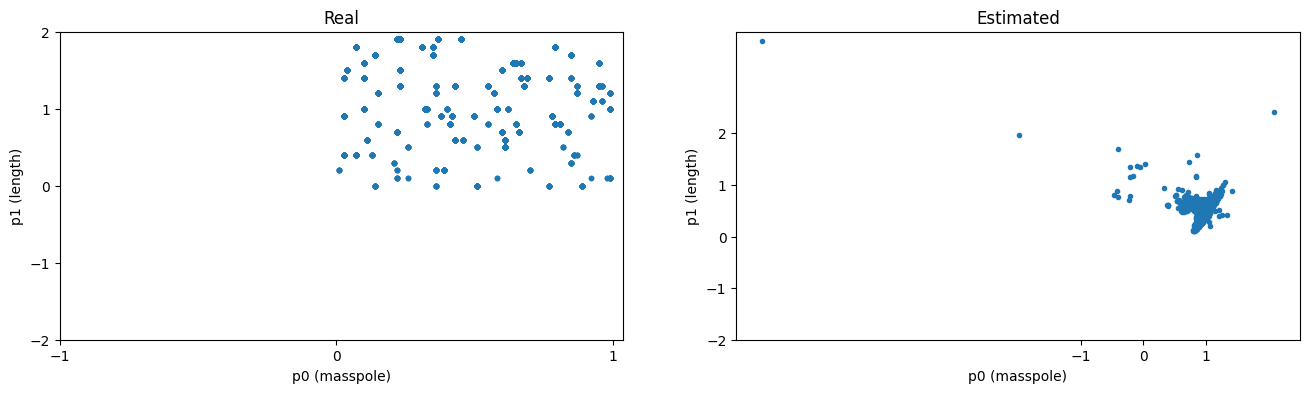

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# df = results.loc[results.episode == 3]
df = results

axs[0].scatter(x=df['p0'], y=df['p1'], marker='.')
axs[1].scatter(x=df['estimated_p0'], y=df['estimated_p1'], marker='.')

axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

In [33]:
from sklearn.cluster import KMeans
import numpy as np
X = df[['p0', 'p1']]
kmeans = KMeans(n_clusters=5, random_state=50, n_init="auto").fit(X)
kmeans.labels_
# kmeans.predict([[0, 0], [12, 3]])
# kmeans.cluster_centers_

array([3, 3, 3, ..., 1, 1, 1], dtype=int32)

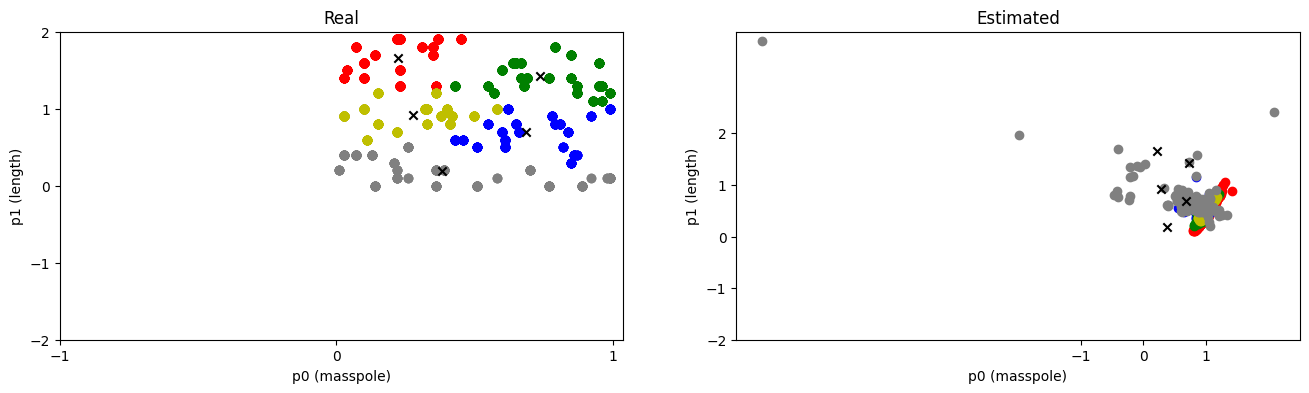

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

colors = ['r', 'b', 'g', 'y', 'gray']

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = X[kmeans.labels_ == label]
    axs[0].scatter(cluster_points['p0'], cluster_points['p1'], color=colors[i])
axs[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')

for i, label in enumerate(np.unique(kmeans.labels_)):
    cluster_points = df[kmeans.labels_ == label]
    axs[1].scatter(cluster_points['estimated_p0'], cluster_points['estimated_p1'], color=colors[i])
axs[1].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='black', marker='x')


axs[0].set_title('Real')
axs[1].set_title('Estimated')

for ax in axs:
    ax.set_ylabel('p1 (length)')
    ax.set_xlabel('p0 (masspole)')
    ax.set_yticks(range(-2,3))
    ax.set_xticks(range(-1,2))

plt.show()

# Evaluation

In [35]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.009,0.62,1.2,0.978,0.509,0.001,0.008,0.007,0.009,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.209,0.62,1.2,0.979,0.503,0.002,0.003,0.008,0.009,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.408,0.62,1.2,0.980,0.495,0.004,0.001,0.008,0.010,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.614,0.62,1.2,0.978,0.482,0.005,0.006,0.003,0.005,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.827,0.62,1.2,0.974,0.467,0.007,0.011,0.002,0.005,0.0


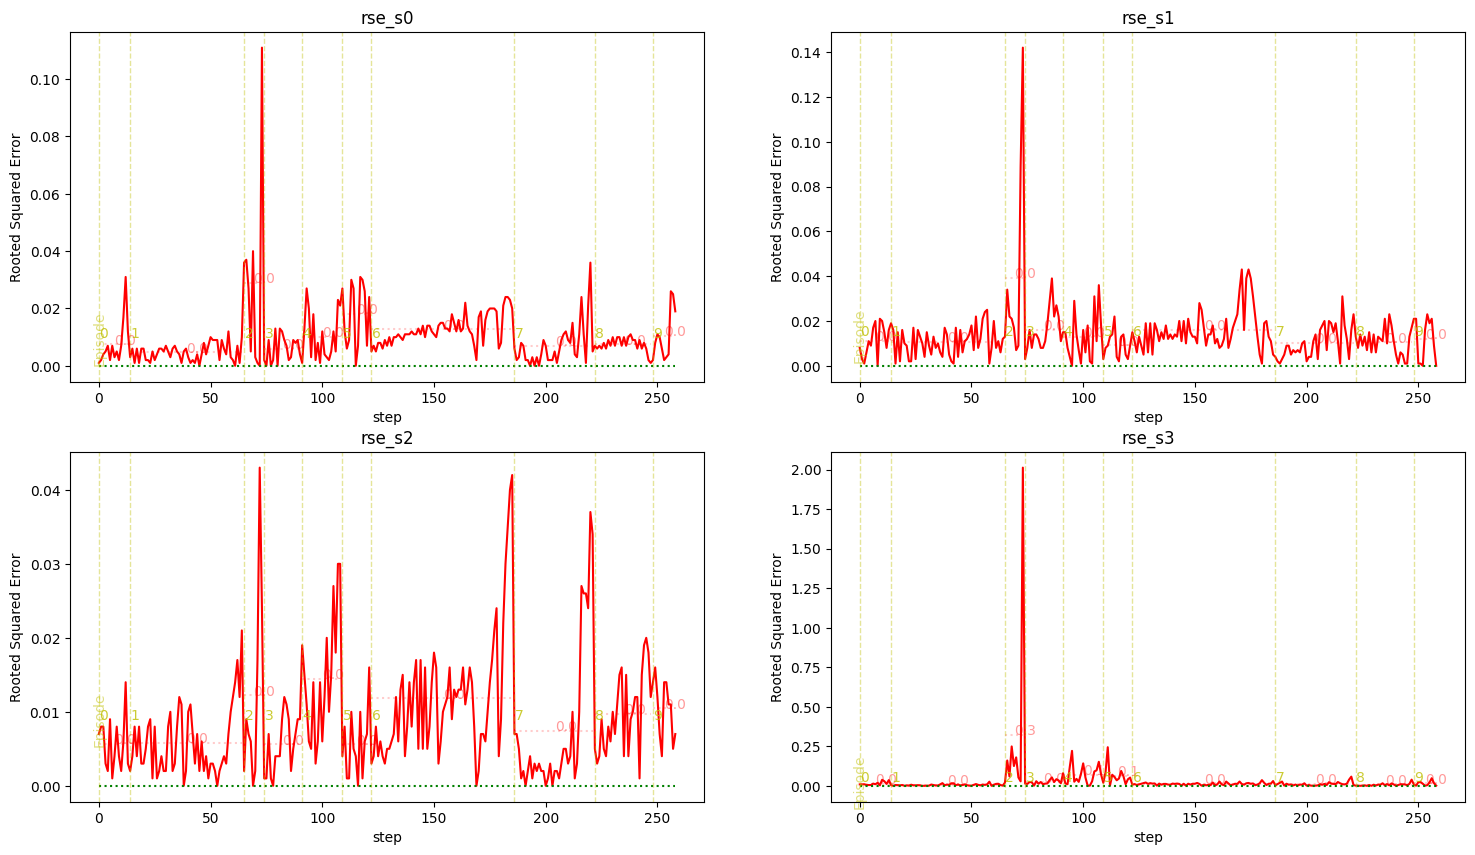

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

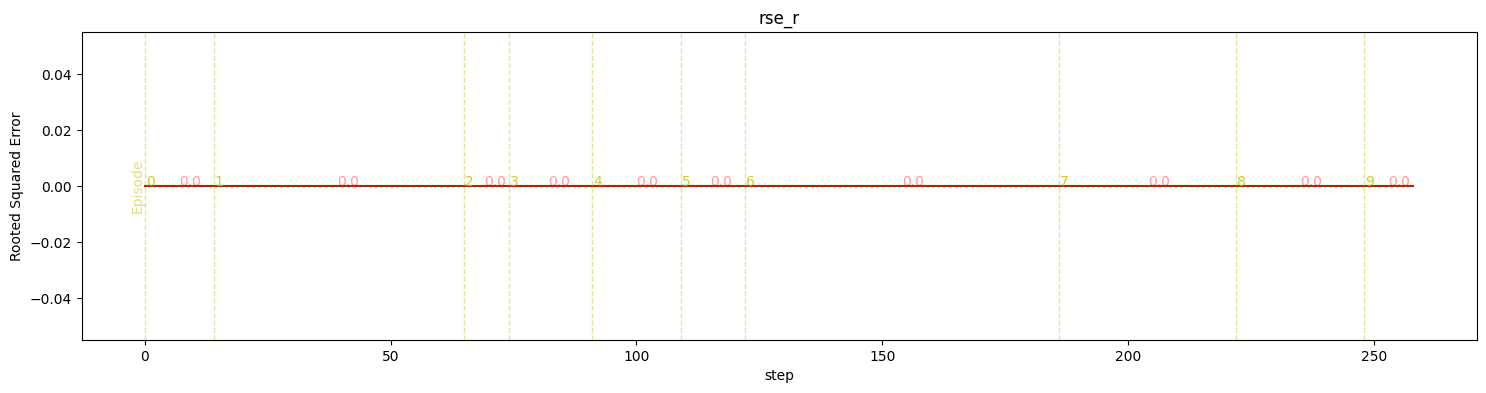

In [37]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

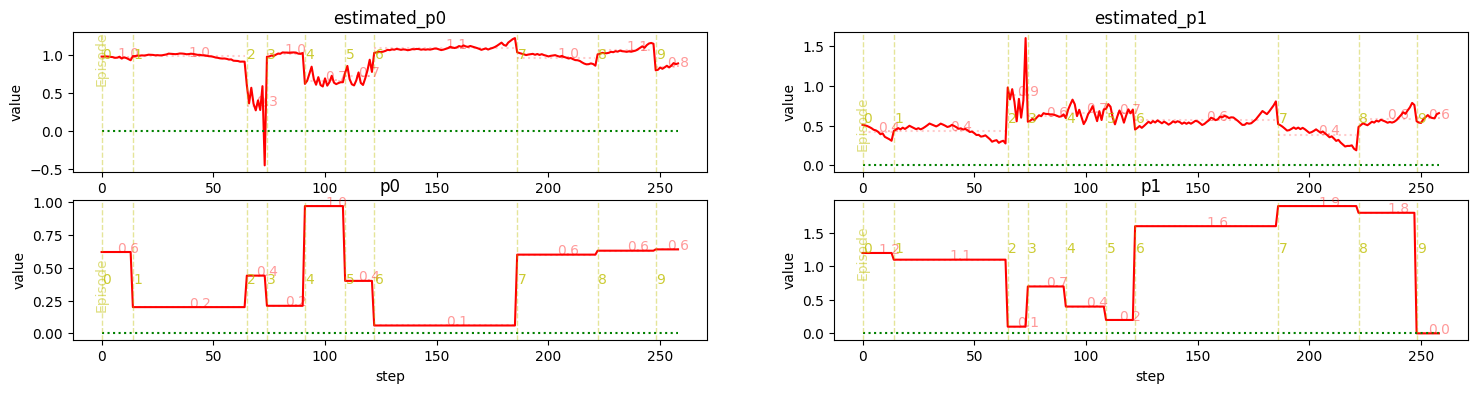

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')
data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='value')
data.plot_value_through_episodes(axs[1][1], results, 'p1', y_label='value')
plt.show()

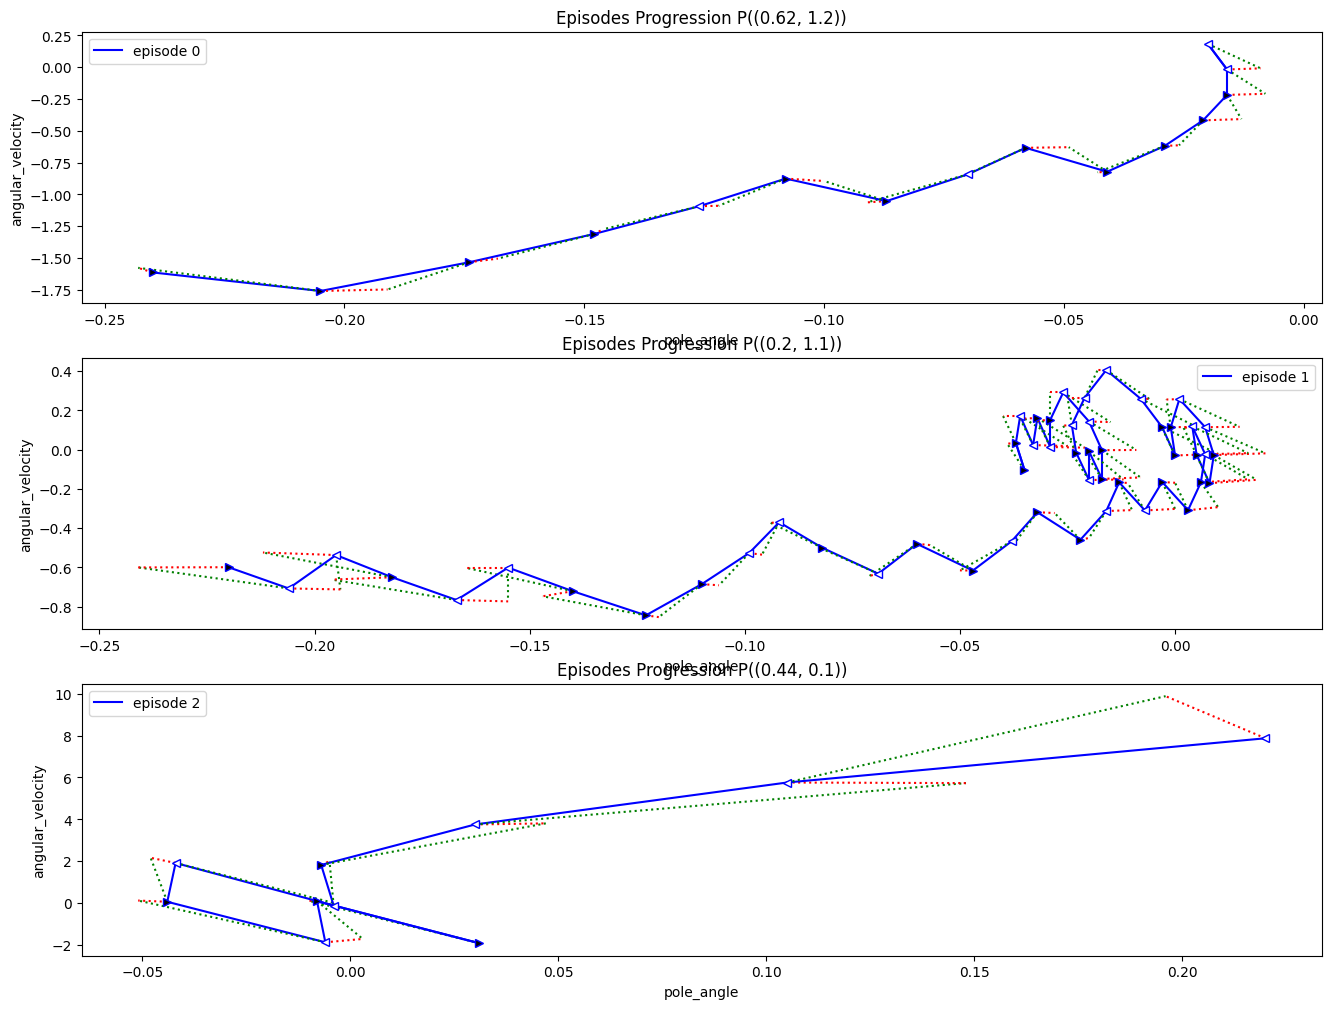

In [39]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()